In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(2, 2))

<Figure size 200x200 with 0 Axes>

<Figure size 200x200 with 0 Axes>

## 图像金字塔

### 高斯金字塔
- 去除偶数行和偶数列，用于压缩图像尺寸

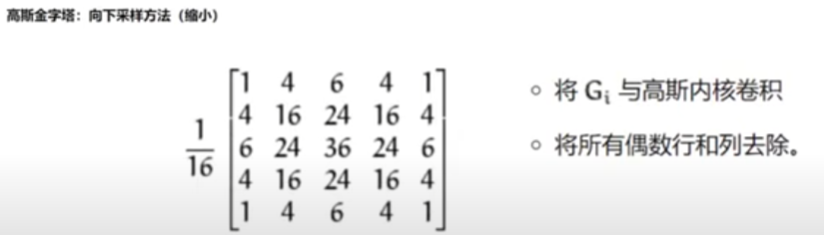

img.shape (1706, 1279, 3)
up.shape (3412, 2558, 3)
down.shape (853, 640, 3)


(<Axes: title={'center': 'updown'}>,
 Text(0.5, 1.0, 'updown'),
 (-0.5, 1278.5, 1705.5, -0.5))

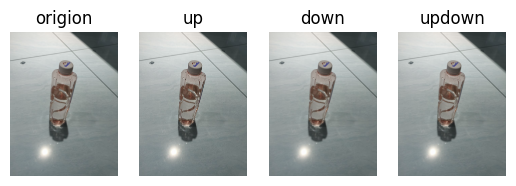

In [ ]:
img = cv2.imread('./assets/1.jpg')

print('img.shape', img.shape)
# 金字塔上采样
up = cv2.pyrUp(img)
print('up.shape', up.shape)
down = cv2.pyrDown(img)
print('down.shape', down.shape)
# 先上采样，再下采样，模糊化
updown = cv2.pyrDown(up)

plt.subplot(241), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(242), plt.imshow(up), plt.title("up"), plt.axis('off')
plt.subplot(243), plt.imshow(down), plt.title("down"), plt.axis('off')
plt.subplot(244), plt.imshow(updown), plt.title("updown"), plt.axis('off')

### 拉普拉斯金字塔

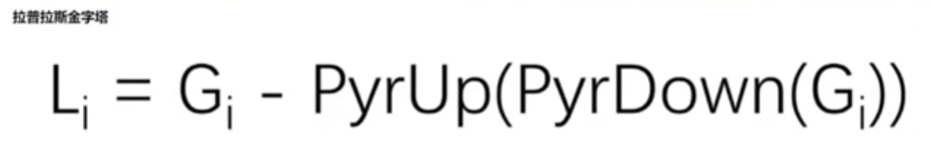

(<Axes: title={'center': 'll5'}>,
 Text(0.5, 1.0, 'll5'),
 (-0.5, 1278.5, 1705.5, -0.5))

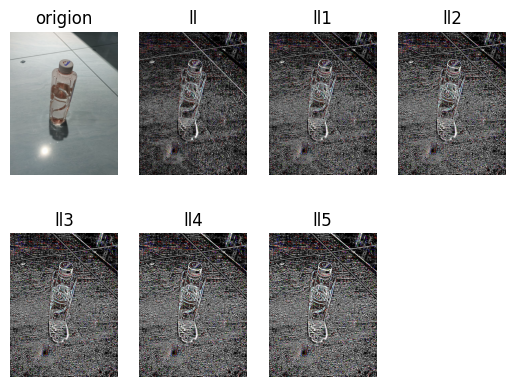

In [7]:
img = cv2.imread('./assets/1.jpg')

down = cv2.pyrDown(img)
down_up = cv2.pyrUp(down)
down1 = cv2.pyrDown(down_up)
down_up1 = cv2.pyrUp(down1)
down2 = cv2.pyrDown(down_up1)
down_up2 = cv2.pyrUp(down2)
down3 = cv2.pyrDown(down_up2)
down_up3 = cv2.pyrUp(down3)
down4 = cv2.pyrDown(down_up3)
down_up4 = cv2.pyrUp(down4)
down5 = cv2.pyrDown(down_up4)
down_up5 = cv2.pyrUp(down5)
down_up = cv2.resize(down_up, (img.shape[1], img.shape[0]))
ll = img - down_up
down_up1 = cv2.resize(down_up1, (img.shape[1], img.shape[0]))
ll1 = img - down_up1
down_up2 = cv2.resize(down_up2, (img.shape[1], img.shape[0]))
ll2 = img - down_up2
down_up3 = cv2.resize(down_up3, (img.shape[1], img.shape[0]))
ll3 = img - down_up3
down_up4 = cv2.resize(down_up4, (img.shape[1], img.shape[0]))
ll4 = img - down_up4
down_up5 = cv2.resize(down_up5, (img.shape[1], img.shape[0]))
ll5 = img - down_up5

plt.subplot(241), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(242), plt.imshow(ll), plt.title("ll"), plt.axis('off')
plt.subplot(243), plt.imshow(ll1), plt.title("ll1"), plt.axis('off')
plt.subplot(244), plt.imshow(ll2), plt.title("ll2"), plt.axis('off')
plt.subplot(245), plt.imshow(ll3), plt.title("ll3"), plt.axis('off')
plt.subplot(246), plt.imshow(ll4), plt.title("ll4"), plt.axis('off')
plt.subplot(247), plt.imshow(ll5), plt.title("ll5"), plt.axis('off')


### 轮廓检测

- RETR EXTERNAL:只检索最外面的轮廓:
- RETR LIST:检索所有的轮腐，并将其保存到一条表当中;
- RETR_CCOMP:检索所有的轮，并将他们组织为两层:顶层是各部分的外部边界，第二层是空洞的边界
- RETR TREE:检索所有的轮廓，并重构嵌套轮的整个层次:

(<Axes: title={'center': 'contours2'}>,
 Text(0.5, 1.0, 'contours2'),
 (-0.5, 1278.5, 1705.5, -0.5))

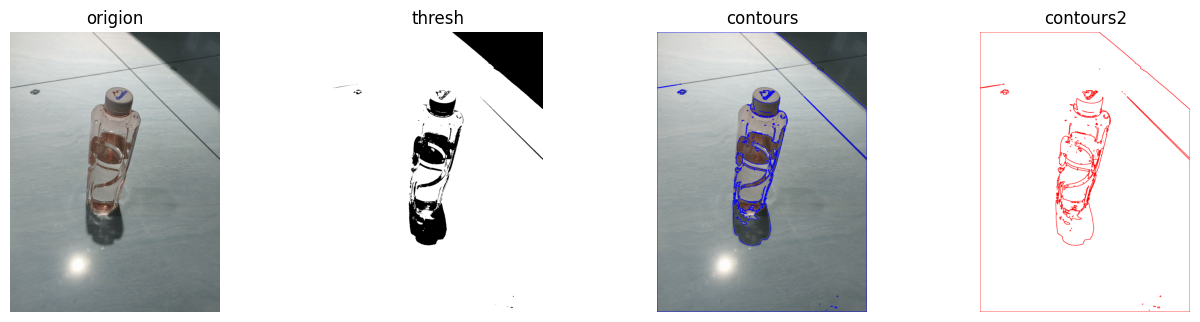

In [ ]:
img = cv2.imread('./assets/1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

draw_img = img.copy()
res = cv2.drawContours(draw_img, contours, -1, (0, 0, 255), 2)
height, width = img.shape[:2]
whiteboard = np.ones((height, width, 3), dtype=np.uint8) * 255
res2 = cv2.drawContours(whiteboard, contours, -1, (255, 0, 0), 2)

plt.figure(figsize=(16, 8))
plt.subplot(241), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(242), plt.imshow(thresh, cmap='gray'), plt.title("thresh"), plt.axis('off')
plt.subplot(243), plt.imshow(res), plt.title("contours"), plt.axis('off')
plt.subplot(244), plt.imshow(res2), plt.title("contours2"), plt.axis('off')

### 轮廓特征

In [21]:
cnt = contours[0]
# 轮廓面积
print(cv2.contourArea(cnt))
# 轮廓周长
print(cv2.arcLength(cnt, True))

2047086.5
6767.759796977043


### 轮廓近似

(355, 1, 2)
(6, 1, 2)


(<Axes: title={'center': 'approx'}>,
 Text(0.5, 1.0, 'approx'),
 (-0.5, 1278.5, 1705.5, -0.5))

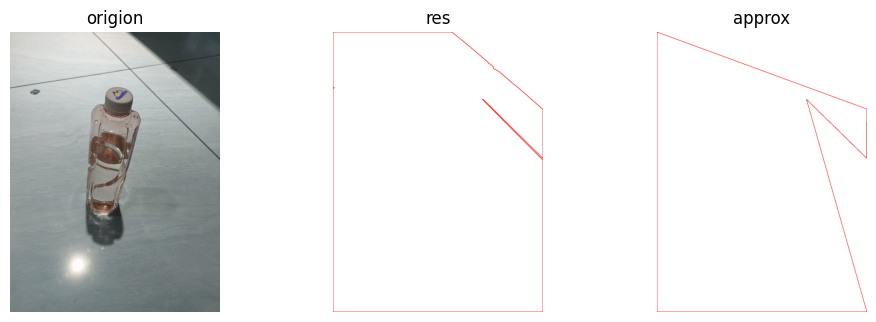

In [40]:
img = cv2.imread('./assets/1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

cnt = contours[0]
print(cnt.shape)

# epsilon 越小，细节越多
epsilon = 0.04 * cv2.arcLength(cnt, True)
approx = cv2.approxPolyDP(cnt, epsilon, True)
print(approx.shape)

height, width = img.shape[:2]
whiteboard = np.ones((height, width, 3), dtype=np.uint8) * 255
res = cv2.drawContours(whiteboard, [cnt], -1, (255, 0, 0), 2)
whiteboard2 = np.ones((height, width, 3), dtype=np.uint8) * 255
res2 = cv2.drawContours(whiteboard2, [approx], -1, (255, 0, 0), 2)

plt.figure(figsize=(16, 8))
plt.subplot(241), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(242), plt.imshow(res), plt.title("res"), plt.axis('off')
plt.subplot(243), plt.imshow(res2), plt.title("approx"), plt.axis('off')

### 边界矩形

(<Axes: title={'center': 'rect'}>,
 Text(0.5, 1.0, 'rect'),
 (-0.5, 1278.5, 1705.5, -0.5))

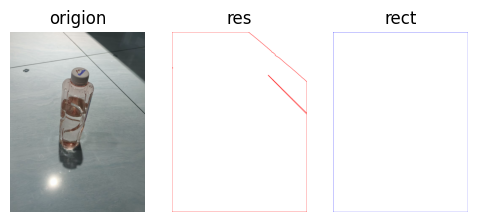

In [47]:
img = cv2.imread('./assets/1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

cnt = contours[0]

x, y, w, h = cv2.boundingRect(cnt)

height, width = img.shape[:2]
whiteboard = np.ones((height, width, 3), dtype=np.uint8) * 255
res = cv2.drawContours(whiteboard, [cnt], -1, (255, 0, 0), 2)

whiteboard2 = np.ones((height, width, 3), dtype=np.uint8) * 255
res2 = cv2.rectangle(whiteboard2, (x, y), (x + w, y + h), (0, 0, 255), 2)

plt.figure(figsize=(8, 8))
plt.subplot(241), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(242), plt.imshow(res), plt.title("res"), plt.axis('off')
plt.subplot(243), plt.imshow(res2), plt.title("rect"), plt.axis('off')

### 外接圆

(119, 104) 114


(<Axes: title={'center': 'circle'}>,
 Text(0.5, 1.0, 'circle'),
 (-0.5, 247.5, 182.5, -0.5))

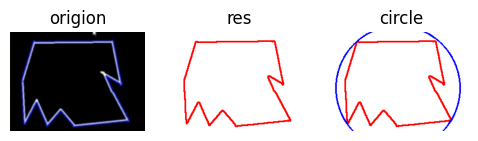

In [50]:
img = cv2.imread('./assets/2.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

cnt = contours[0]

(x, y), r = cv2.minEnclosingCircle(cnt)

height, width = img.shape[:2]
whiteboard = np.ones((height, width, 3), dtype=np.uint8) * 255
res = cv2.drawContours(whiteboard, [cnt], -1, (255, 0, 0), 2)

whiteboard2 = whiteboard.copy()
center = (int(x), int(y))
radius = int(r)
print(center, radius)
res2 = cv2.circle(whiteboard2, center, radius, (0, 0, 255), 2)

plt.figure(figsize=(8, 8))
plt.subplot(241), plt.imshow(img), plt.title("origion"), plt.axis('off')
plt.subplot(242), plt.imshow(res), plt.title("res"), plt.axis('off')
plt.subplot(243), plt.imshow(res2), plt.title("circle"), plt.axis('off')